# RLBench Eval Run Inspector

Inspect planner vs policy outputs for one run directory.

This notebook provides:
- side-by-side video playback (planner/policy)
- rollout metadata preview
- action and state value plots over time


In [1]:
from __future__ import annotations

import base64
import json
from pathlib import Path
from typing import Any

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display

RUN_DIR = Path("/home/ngocbach@ad.asu.edu/Desktop/cross_model_learning_based_robot_control/output/rlbench_eval_debug/all_tasks/put_rubbish_in_bin/single_run_var0_seed0/run_000")
CAMERA = "front_rgb"  # or "wrist_rgb"

RUN_DIR

PosixPath('/home/ngocbach@ad.asu.edu/Desktop/cross_model_learning_based_robot_control/output/rlbench_eval_debug/all_tasks/put_rubbish_in_bin/single_run_var0_seed0/run_000')

In [2]:
def _episode_ids(run_dir: Path) -> list[int]:
    planner_root = run_dir / "planner" / "episodes"
    policy_root = run_dir / "policy" / "episodes"
    planner_eps = {p.name for p in planner_root.glob("episode*") if p.is_dir()}
    policy_eps = {p.name for p in policy_root.glob("episode*") if p.is_dir()}
    common = sorted(planner_eps & policy_eps)
    out: list[int] = []
    for name in common:
        try:
            out.append(int(name.replace("episode", "")))
        except ValueError:
            continue
    return sorted(out)


def _episode_dir(run_dir: Path, source: str, ep_idx: int) -> Path:
    return run_dir / source / "episodes" / f"episode{ep_idx}"


def _load_npz(episode_dir: Path) -> dict[str, np.ndarray]:
    arr = np.load(episode_dir / "rollout_arrays.npz", allow_pickle=True)
    return {k: np.asarray(arr[k]) for k in arr.files}


def _load_info(episode_dir: Path) -> dict[str, Any]:
    info_path = episode_dir / "rollout_info.json"
    if not info_path.is_file():
        return {}
    with open(info_path, "r", encoding="utf-8") as f:
        return json.load(f)


def _video_html(path: Path, width: int = 480) -> str:
    if not path.is_file():
        return f"<div style='color:#d00'>Missing video: {path}</div>"
    ext = path.suffix.lower().lstrip(".")
    mime = "video/mp4" if ext == "mp4" else "video/webm"
    data = base64.b64encode(path.read_bytes()).decode("ascii")
    return (
        f"<video width='{width}' controls preload='metadata' "
        f"style='border:1px solid #aaa; border-radius:6px'>"
        f"<source src='data:{mime};base64,{data}' type='{mime}'></video>"
    )


def show_videos_side_by_side(run_dir: Path, ep_idx: int, camera: str = "front_rgb", width: int = 480) -> None:
    planner_vid = _episode_dir(run_dir, "planner", ep_idx) / f"{camera}.mp4"
    policy_vid = _episode_dir(run_dir, "policy", ep_idx) / f"{camera}.mp4"

    html = f"""
    <div style='display:flex; gap:16px; align-items:flex-start'>
      <div>
        <div style='font-weight:600; margin-bottom:6px'>Planner ({camera})</div>
        {_video_html(planner_vid, width=width)}
      </div>
      <div>
        <div style='font-weight:600; margin-bottom:6px'>Policy ({camera})</div>
        {_video_html(policy_vid, width=width)}
      </div>
    </div>
    """
    display(HTML(html))


print("Episodes found:", _episode_ids(RUN_DIR))

Episodes found: [0, 1]


In [3]:
def _plot_matrix_compare(
    planner: np.ndarray,
    policy: np.ndarray,
    title: str,
    ylabel_prefix: str,
    max_dims: int = 8,
) -> None:
    if planner.ndim != 2 or policy.ndim != 2:
        print(f"Skip {title}: expected 2D arrays, got {planner.shape=} {policy.shape=}")
        return

    dims = min(max_dims, planner.shape[1], policy.shape[1])
    rows, cols = 4, 2
    fig, axes = plt.subplots(rows, cols, figsize=(14, 10), sharex=True)
    fig.suptitle(title)

    for i in range(rows * cols):
        ax = axes[i // cols, i % cols]
        if i >= dims:
            ax.axis("off")
            continue
        ax.plot(np.arange(planner.shape[0]), planner[:, i], label="planner", linewidth=1.5)
        ax.plot(np.arange(policy.shape[0]), policy[:, i], label="policy", linewidth=1.5)
        ax.set_ylabel(f"{ylabel_prefix}[{i}]")
        ax.grid(alpha=0.3)
        if i == 0:
            ax.legend(loc="best")
    for ax in axes[-1, :]:
        ax.set_xlabel("timestep")
    plt.tight_layout()
    plt.show()


def inspect_episode(run_dir: Path, ep_idx: int, camera: str = "front_rgb") -> None:
    planner_dir = _episode_dir(run_dir, "planner", ep_idx)
    policy_dir = _episode_dir(run_dir, "policy", ep_idx)

    planner_npz = _load_npz(planner_dir)
    policy_npz = _load_npz(policy_dir)

    planner_info = _load_info(planner_dir)
    policy_info = _load_info(policy_dir)

    print(f"Episode {ep_idx}")
    print("Planner info:", planner_info)
    print("Policy info:", policy_info)

    show_videos_side_by_side(run_dir, ep_idx, camera=camera, width=500)

    _plot_matrix_compare(
        planner_npz.get("action_aligned", np.zeros((0, 0))),
        policy_npz.get("action_aligned", np.zeros((0, 0))),
        title=f"Episode {ep_idx} - Action (aligned)",
        ylabel_prefix="action",
    )
    _plot_matrix_compare(
        planner_npz.get("eef_state", np.zeros((0, 0))),
        policy_npz.get("eef_state", np.zeros((0, 0))),
        title=f"Episode {ep_idx} - EEF State",
        ylabel_prefix="eef",
    )
    _plot_matrix_compare(
        planner_npz.get("joint_state", np.zeros((0, 0))),
        policy_npz.get("joint_state", np.zeros((0, 0))),
        title=f"Episode {ep_idx} - Joint State",
        ylabel_prefix="joint",
    )


def inspect_all_episodes(run_dir: Path, camera: str = "front_rgb") -> None:
    for ep in _episode_ids(run_dir):
        inspect_episode(run_dir, ep, camera=camera)


Episode 1
Planner info: {'source': 'planner', 'run_index': 0, 'seed': 0, 'variation': 0, 'episode_index': 1, 'instruction': 'paper in trash bin', 'segment_start_index': 92, 'segment_end_index': 137}
Policy info: {'source': 'policy', 'run_index': 0, 'seed': 0, 'variation': 0, 'episode_index': 1, 'instruction': 'paper in trash bin', 'policy_success': False, 'policy_errors': []}


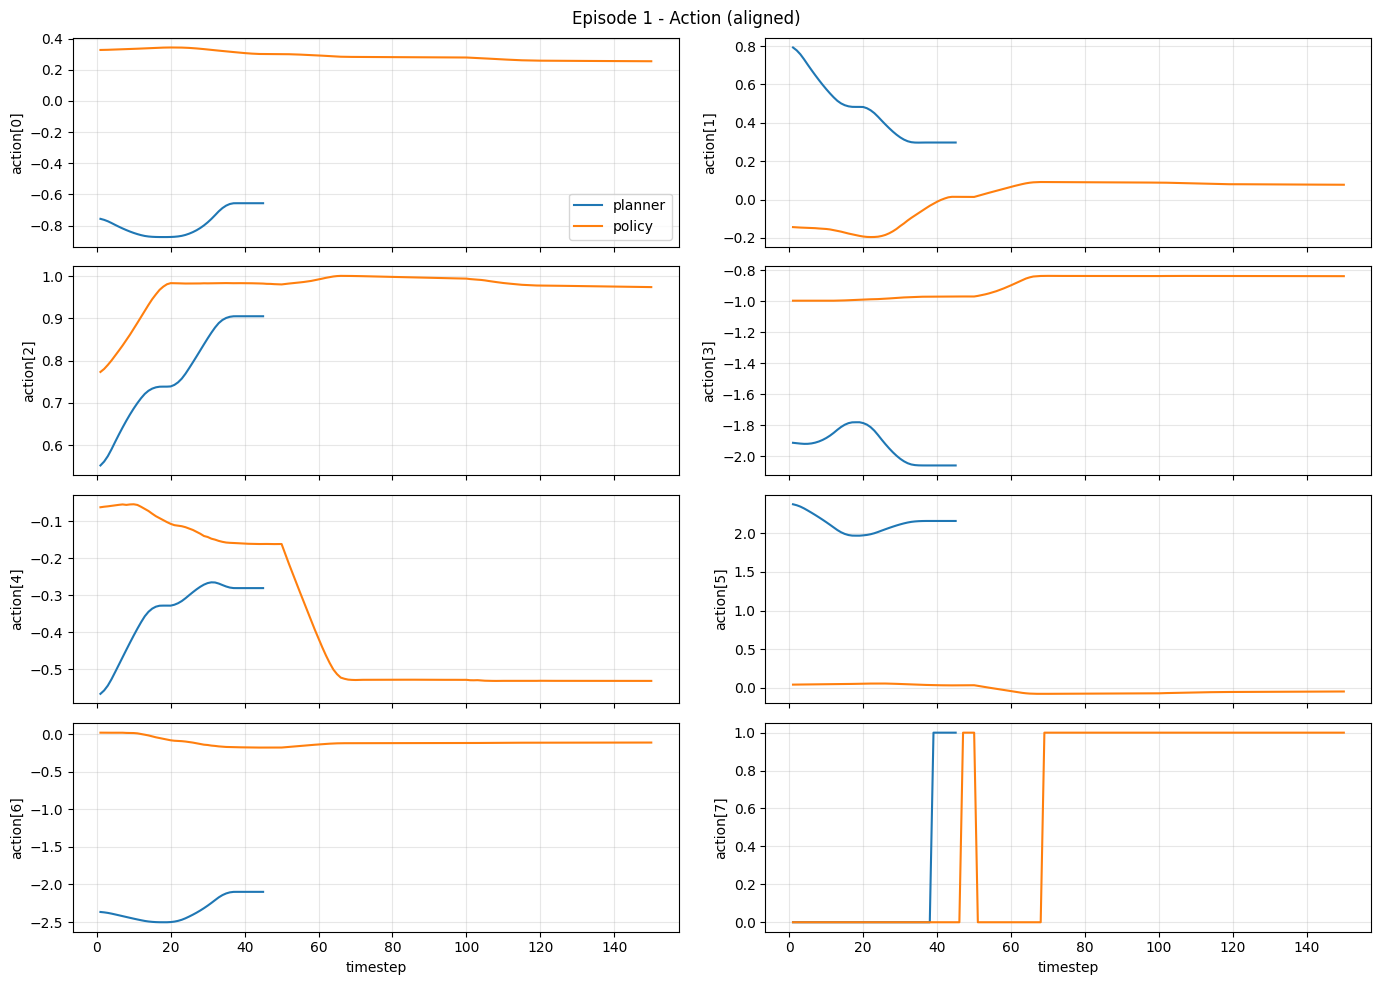

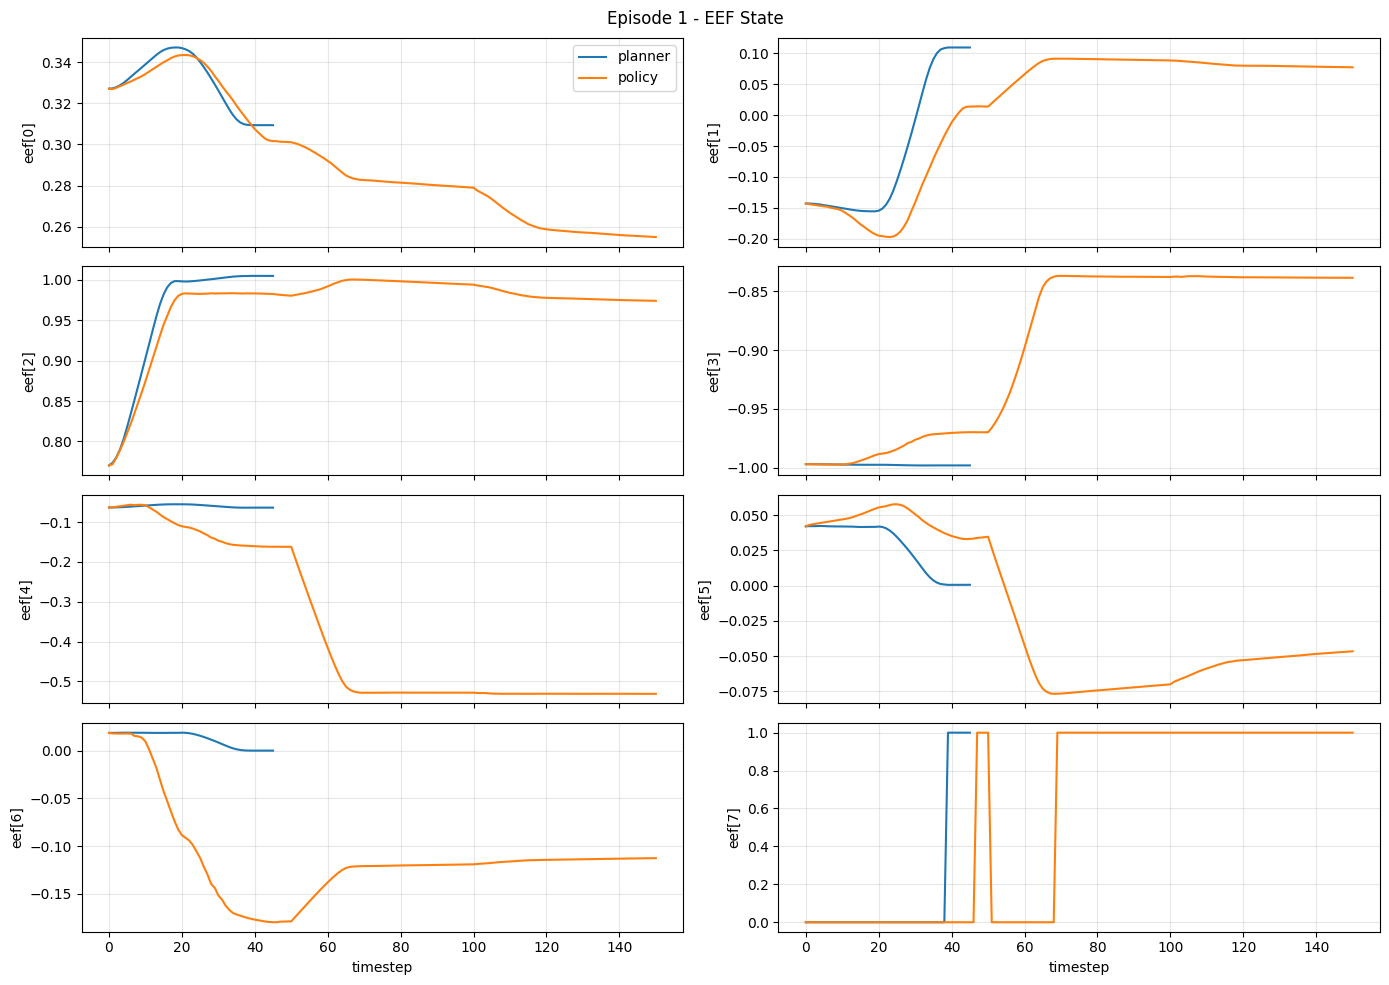

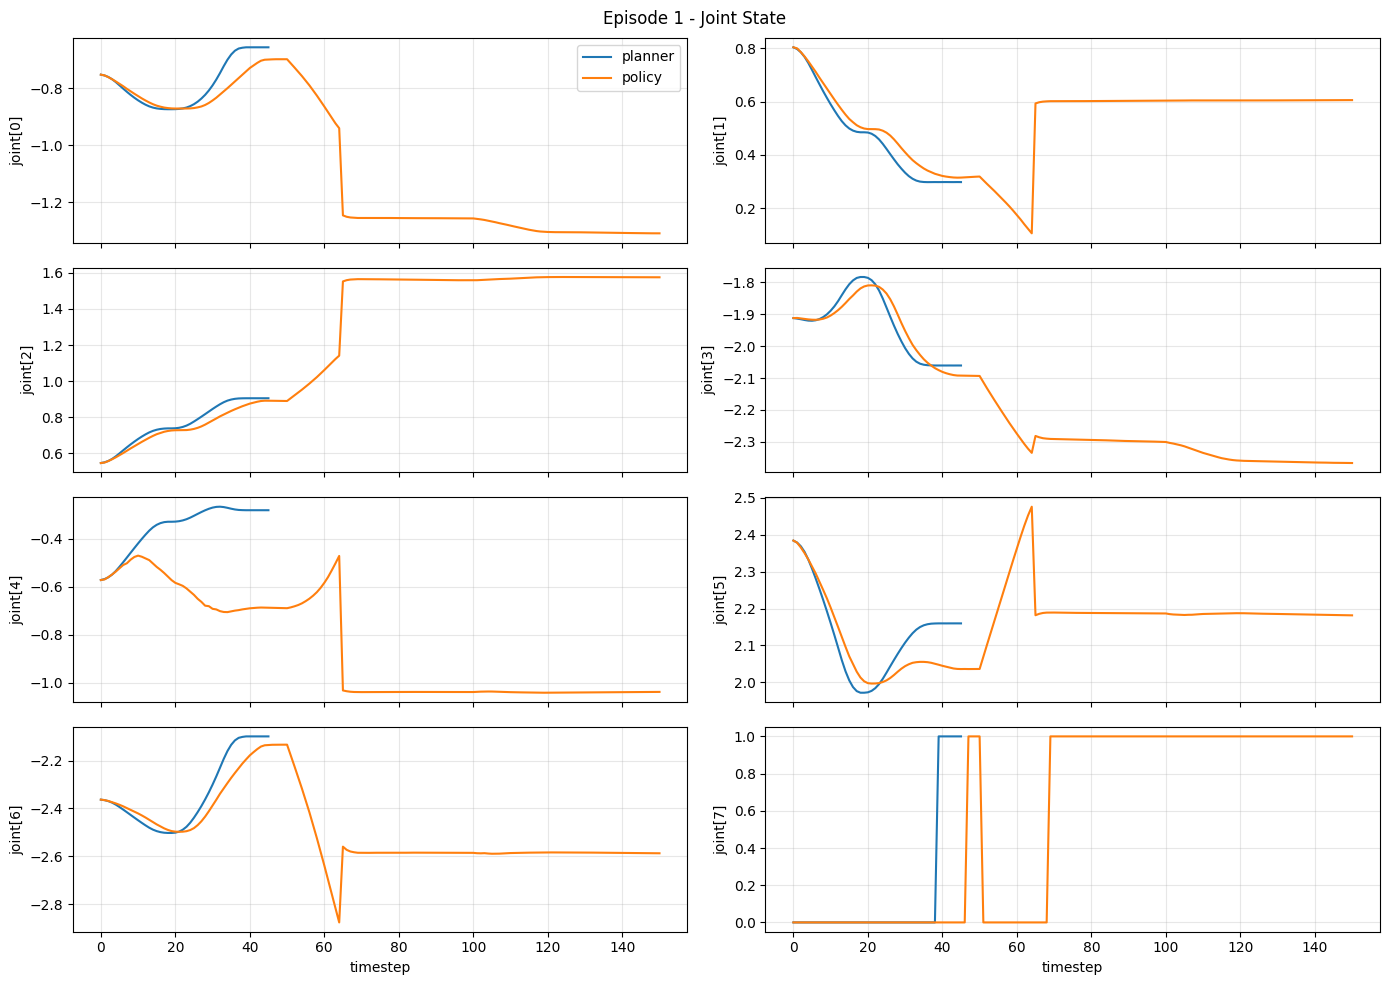

In [4]:
# Pick one episode to inspect.
EPISODE_IDX = 1
inspect_episode(RUN_DIR, EPISODE_IDX, camera=CAMERA)

# Uncomment to inspect every episode in the run:
# inspect_all_episodes(RUN_DIR, camera=CAMERA)
